In [1]:
!pip install tensorflow scikit-learn matplotlib -q

In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

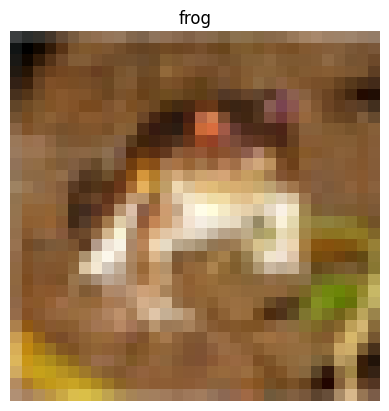

In [5]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.imshow(X_train[0])
plt.title(class_names[y_train[0][0]])
plt.axis('off')
plt.show()

In [6]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 94ms/step - accuracy: 0.4251 - loss: 1.5800 - val_accuracy: 0.4982 - val_loss: 1.3890
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.5744 - loss: 1.2077 - val_accuracy: 0.5802 - val_loss: 1.1777
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 87ms/step - accuracy: 0.6295 - loss: 1.0557 - val_accuracy: 0.6332 - val_loss: 1.0714
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.6689 - loss: 0.9499 - val_accuracy: 0.6652 - val_loss: 0.9750
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.7000 - loss: 0.8628 - val_accuracy: 0.6906 - val_loss: 0.9051
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.7259 - loss: 0.7932 - val_accuracy: 0.7108 - val_loss: 0.8680
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 85ms/step - accuracy: 0.7433 - loss: 0.7388 - val_accuracy: 0.7014 - val_loss: 0.8784
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 88ms/step - accuracy: 0.7618 - loss: 0.6856 - 

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7129 - loss: 0.8791
Test Accuracy: 0.7128999829292297


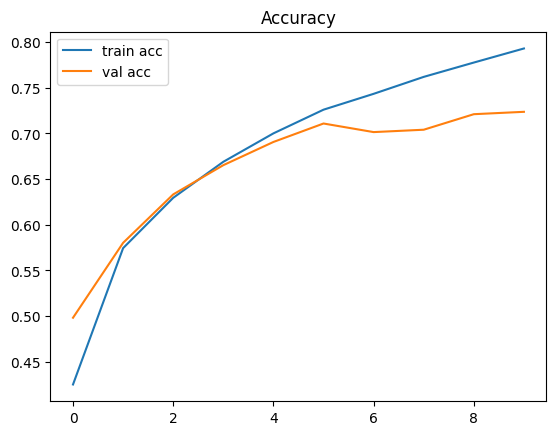

In [9]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted class: horse


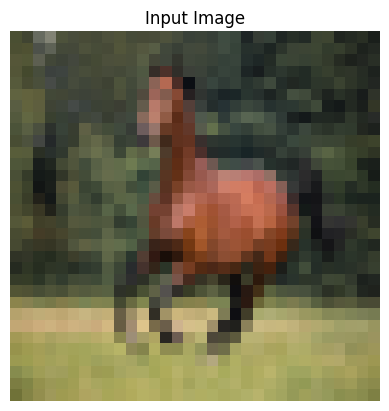

In [12]:
from tensorflow.keras.preprocessing import image
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_path = "horse.jpg"

# Load image
img = Image.open(img_path).resize((32,32))

# Convert to array
img_array = np.array(img) / 255.0

# Reshape for model
img_array = img_array.reshape(1,32,32,3)

# Predict
prediction = model.predict(img_array)
class_index = np.argmax(prediction)

print("Predicted class:", class_names[class_index])

# Show image
plt.imshow(img)
plt.title("Input Image")
plt.axis('off')
plt.show()